# investigating inclusion of short-lived spiral tips in MSR calculations
Tim Tyree<br>
6.14.2025

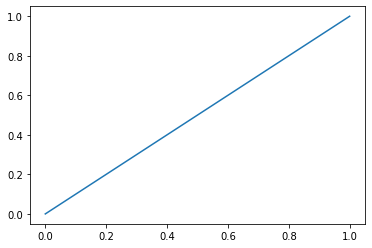

In [1]:
import sys,os
og_stdout=sys.stdout
from lib.my_initialization import *
# os.chdir(nb_dir)
from lib import *
import seaborn as sns
plt.plot([0,1])
# plt.show()
#reset matplotlib settings
import matplotlib as mpl
sns.reset_orig()
mpl.rc_file_defaults()

import warnings
warnings.simplefilter("ignore", UserWarning)
%load_ext autoreload
%autoreload 2

# define module

# TODO: load msr and see if shorter than 100ms pairs are recorded

In [ ]:
#recall WJ's full model range data for LR
msr_dir_bootstrap_fk = '/Users/timothytyree/Documents/GitHub/care/notebooks/Data/from_wjr/positions_fk/200x200/tippos_per_c_001_annihilation_msr.csv'
msr_dir_bootstrap_lr = '/Users/timothytyree/Documents/GitHub/care/notebooks/Data/from_wjr/positions_lr/200x200/tippos_per_001_annihilation_msr.csv'

In [22]:
#LR model trajectories
#per 001
annihil_range_dir_lr = "/Users/timothytyree/Documents/GitHub/care/notebooks/Data/from_wjr/positions_lr/200x200/tippos_per_001_annihilation_range_timeseries.pkl"
creation_range_dir_lr = "/Users/timothytyree/Documents/GitHub/care/notebooks/Data/from_wjr/positions_lr//200x200/tippos_per_001_creation_range_timeseries.pkl"
# annihil_range_dir_lr = "/home/timothytyree/Documents/GitHub/care/notebooks/Data/from_wjr/positions_lr/200x200/tippos_per_001_annihilation_range_timeseries.pkl"
# creation_range_dir_lr = "/home/timothytyree/Documents/GitHub/care/notebooks/Data/from_wjr/positions_lr//200x200/tippos_per_001_creation_range_timeseries.pkl"
assert os.path.exists(annihil_range_dir_lr)
assert os.path.exists(creation_range_dir_lr)
# DS = 0.0025 # cm / px
DT = 1e-3 # s / frame
data_annihil=load_from_pickle(annihil_range_dir_lr)
data_creation=load_from_pickle(creation_range_dir_lr)
df_ranges_annihiln = pd.concat(data_annihil)
df_ranges_creation = pd.concat(data_creation)
print(f"num. trials in cached annihilation ranges: {df_ranges_annihiln['trial_num'].max()}")
print(f"num. trials in cached creation ranges: {df_ranges_creation['trial_num'].max()}")

ImportError: cannot import name 'astype_nansafe' from 'pandas.core.dtypes.cast' (/Users/timothytyree/opt/miniconda3/envs/pyenv/lib/python3.9/site-packages/pandas/core/dtypes/cast.py)

In [ ]:
#FK model trajectories
# #per 005
# annihil_range_dir_fk = "/Users/timothytyree/Documents/GitHub/care/notebooks/Data/from_wjr/positions_fk/200x200/tippos_per_c_005_annihilation_range_timeseries.pkl"
# creation_range_dir_fk = "/Users/timothytyree/Documents/GitHub/care/notebooks/Data/from_wjr/positions_fk/200x200/tippos_per_c_005_creation_range_timeseries.pkl" # 79 trials
# DT = 5e-3 # s / frame
#per 001
# annihil_range_dir_fk = "/home/timothytyree/Documents/GitHub/care/notebooks/Data/from_wjr/positions_fk/200x200/tippos_per_c_001_annihilation_range_timeseries.pkl"
# creation_range_dir_fk = "/home/timothytyree/Documents/GitHub/care/notebooks/Data/from_wjr/positions_fk/200x200/tippos_per_c_001_creation_range_timeseries.pkl"
annihil_range_dir_fk = "/Users/timothytyree/Documents/GitHub/care/notebooks/Data/from_wjr/positions_fk/200x200/tippos_per_c_001_annihilation_range_timeseries.pkl"
creation_range_dir_fk = "/Users/timothytyree/Documents/GitHub/care/notebooks/Data/from_wjr/positions_fk/200x200/tippos_per_c_001_creation_range_timeseries.pkl"
DT = 1e-3 # s / frame
# DS = 0.0025 # cm / px
assert os.path.exists(annihil_range_dir_fk)
assert os.path.exists(creation_range_dir_fk)
data_annihil=load_from_pickle(annihil_range_dir_fk)
data_creation=load_from_pickle(creation_range_dir_fk)
df_ranges_annihiln = pd.concat(data_annihil)
df_ranges_creation = pd.concat(data_creation)
print(f"num. trials in cached annihilation ranges: {df_ranges_annihiln['trial_num'].max()}")
print(f"num. trials in cached creation ranges: {df_ranges_creation['trial_num'].max()}")
#TODO: dev dRdt routine
#TODO: eval dRdt routine
# #TODO: record
# dict_dRdt_fk= dict(df_dRdt_creation=df_dRdt_creation,
#                    df_bootstrapped_creation=df_bootstrapped_creation,
#                    df_dRdt_annihiln=df_dRdt_annihiln,
#                    df_bootstrapped_annihiln=df_bootstrapped_annihiln
#                   )

In [20]:
directory = f"{nb_dir}/Data/from_wjr/positions_fk/200x200/tippos_per_c_001_creation_range_timeseries.pkl"
os.path.exists(directory)

True

In [21]:
data = load_from_pickle(directory)
data.keys()

ImportError: cannot import name 'astype_nansafe' from 'pandas.core.dtypes.cast' (/Users/timothytyree/opt/miniconda3/envs/pyenv/lib/python3.9/site-packages/pandas/core/dtypes/cast.py)

In [19]:
arr['arr_0']

array([9.10219754, 5.43783045, 4.29534632, ..., 3.12409987, 1.61554944,
       1.78044938])

In [ ]:
#plot expected
fig,ax=plt.subplots(figsize=(4,4.2))
ax.plot(x_values,4*9.5*1e-3*x_values,'--',lw=2,alpha=0.8,c='C1')
# ax.plot(x_values,4*1.8*1e-3*x_values,'--',lw=2,alpha=0.8,c='C0')
#plot data
ax.plot(x_values,y_values,lw=2,alpha=0.8,c=c)
ax.fill_between(x_values,y_values-yerr_values,y_values+yerr_values,lw=2,alpha=0.4,color=c)
format_plot(ax=ax,xlabel=r'$t_f-t$ (ms)',ylabel=r'MSR (cm$^2$)')
# ax.set_xlim([0,200])
ax.set_ylim([0,8])
plt.show()

# dev

In [2]:
trial_num=300
# log_folder_parquet='/home/timothytyree/Documents/GitHub/care/notebooks/Data/from_wjr/tippos_per_001_log/'
log_folder_parquet=f'{nb_dir}/Data/from_wjr/tippos_per_001_log/'
g=load_parquet_by_trial_num(trial_num=trial_num,folder_parquet=log_folder_parquet)
g.head()

,index,t,n,x,y,trial_num
0,0,1.0,20,0.1,99.1,300
1,1,1.0,20,0.5,155.6,300
2,2,1.0,20,1.0,173.3,300
3,3,1.0,20,1.7,103.0,300
4,4,1.0,20,1.3,198.2,300


In [3]:
dict_msr=routine_annihilation_analysis_pbc(trial_num=int(trial_num),
        log_folder_parquet=log_folder_parquet,
        DS=0.025, #cm/pixel
        DT=1., #ms/frame
        width=200.,  #pixels
        height=200., #pixels
        tavg1=0.,  #moving average window, in ms
        tavg2=14., #ms #savgol_filter time window performed on R  #12 ms was no longer smooth
        min_termination_time=100.,
#         min_termination_time=0.,
        min_duration_thresh=1., #ms #minimum lifetime for a spiral tip position to be considered
        max_Rfinal_thresh=0.5,  #cm
        max_dtmax_thresh= 0.,   #cm # max disagreement between tmax for _self relative to _other
        round_t_to_n_digits=7,
        t_col='t',
        pid_col='particle',
        trial_col='trial_num',
        use_tavg2=True, #unsmoothed R is preserved through R_nosavgol
        testing=False,
        printing=False,
        use_dask=False,
        npartitions=1)

NameError: name 'routine_annihilation_analysis_pbc' is not defined

# dev

In [1]:
#TODO: recall Fig. 2a from the chaos paper
#TODO: replot it with min termination time reduced to zero.
#TODO: send ^that to WJ.